<a href="https://colab.research.google.com/github/MarcosRigal/AP/blob/main/adapted_performance_metrics_for_oc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparación de MAE y TC vs. MAE_int y TC_int

En este notebook se ilustra de forma práctica lo presentado en el paper:

- Se definen las métricas ordinales **MAE** y **TC** a partir de la matriz de confusión.
- Se adaptan estas métricas a escala intervalar (**MAE_int** y **TC_int**) usando la distancia entre intervalos y el número de instancias sobre la longitud del intervalo.
- Se estudia el efecto de modificar la longitud del último intervalo mediante un barrido de valores para *x*.

Se usan dos matrices de confusión simuladas con tres clases y un conjunto de datos balanceado.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Configuración de gráficos
plt.style.use('default')
plt.rcParams['figure.figsize'] = (8, 5)

In [4]:
# Definición de las matrices de confusión de los clasificadores
# Filas = predicción, Columnas = valor observado

# Clasificador A
conf_A = np.array([
    [3, 2, 1],
    [2, 2, 2],
    [0, 1, 2]
])

# Clasificador B
conf_B = np.array([
    [3, 2, 2],
    [2, 2, 1],
    [0, 1, 2]
])

# Número de instancias en cada clase (balanceado: 5 por clase)
true_counts = np.array([5, 5, 5])
N = np.sum(true_counts)
r = len(true_counts)

print(f"Total de instancias: {N}")
print(f"Número de clases: {r}")

Total de instancias: 15
Número de clases: 3


In [5]:
# Funciones para calcular las métricas ordinales (MAE y TC)
def mae_ordinal(conf):
    """
    Calcula MAE ordinal = (1/N) * sum(conf[i,j] * |i - j|).
    """
    r = conf.shape[0]
    indices = np.arange(r)
    diff_matrix = np.abs(indices.reshape(-1, 1) - indices.reshape(1, -1))
    mae = np.sum(conf * diff_matrix) / np.sum(conf)
    return mae

def tc_ordinal(conf):
    """
    Calcula TC ordinal usando el costo sensible:
    Para cada error (i != j), se aplica: (N - n_j) / n_i, donde n_i es la suma de la fila i y n_j la suma de la columna j.
    """
    N = np.sum(conf)
    r = conf.shape[0]
    row_sums = np.sum(conf, axis=1)  # Predicción
    col_sums = np.sum(conf, axis=0)  # Valor verdadero
    tc = 0.0
    for i in range(r):
        for j in range(r):
            if i != j:
                weight = (N - col_sums[j]) / row_sums[i]
                error = abs(i - j)
                tc += conf[i, j] * weight * error
    return tc

# Ejemplo de uso
print("Métricas ordinales para clasificador A:")
print("MAE:", mae_ordinal(conf_A))
print("TC:", tc_ordinal(conf_A))

print("\nMétricas ordinales para clasificador B:")
print("MAE:", mae_ordinal(conf_B))
print("TC:", tc_ordinal(conf_B))

Métricas ordinales para clasificador A:
MAE: 0.6
TC: 16.666666666666668

Métricas ordinales para clasificador B:
MAE: 0.6666666666666666
TC: 17.904761904761905


In [6]:
# Funciones para métricas en escala intervalar

def interval_distance(interval_i, interval_j):
    """
    Calcula la distancia entre dos intervalos I_i y I_j usando la fórmula de Hausdorff:
    d(I_i, I_j) = max(|a_j - a_i|, |b_j - b_i|)
    donde cada intervalo se define como (a, b).
    """
    a_i, b_i = interval_i
    a_j, b_j = interval_j
    return max(abs(a_j - a_i), abs(b_j - b_i))

def mae_interval(conf, intervals):
    """
    Calcula MAE en escala intervalar = (1/N) * sum(conf[i,j] * d(I_i, I_j)).
    """
    N = np.sum(conf)
    r = conf.shape[0]
    total = 0.0
    for i in range(r):
        for j in range(r):
            d_ij = interval_distance(intervals[i], intervals[j])
            total += conf[i, j] * d_ij
    return total / N

def tc_interval(conf, intervals, true_counts):
    """
    Calcula TC en escala intervalar:
    1. Se define la longitud de cada intervalo: ℓ_j = b_j - a_j
    2. Se define la densidad: ρ_j = n_j / ℓ_j
    3. Se define el peso para error (i != j):
           ω_int[i,j] = (Σ_{k ≠ j} ρ_k) / ρ_i
    4. Luego, TC_int = sum(conf[i,j] * ω_int[i,j] * d(I_i, I_j)) para i ≠ j.
    """
    r = conf.shape[0]
    lengths = np.array([interval[1] - interval[0] for interval in intervals])
    densities = true_counts / lengths  # ρ_j = n_j/ℓ_j
    total_densities = np.sum(densities)
    tc_int = 0.0
    for i in range(r):
        for j in range(r):
            if i != j:
                weight = (total_densities - densities[j]) / densities[i]
                d_ij = interval_distance(intervals[i], intervals[j])
                tc_int += conf[i, j] * weight * d_ij
    return tc_int

# Ejemplo de uso (usando un conjunto de intervalos arbitrarios)
intervals_example = [(0, 1), (1, 2), (2, 3)]
print("\nEjemplo de MAE_int:", mae_interval(conf_A, intervals_example))
print("Ejemplo de TC_int:", tc_interval(conf_A, intervals_example, true_counts))


Ejemplo de MAE_int: 0.6
Ejemplo de TC_int: 18.0


In [7]:
# Función para definir los intervalos en función de x (longitud del último intervalo)
def define_intervals(x):
    """
    Dado un valor x, define:
    I1 = [0, 1], I2 = [1, 2], I3 = [2, 2 + x]
    """
    return [(0, 1), (1, 2), (2, 2 + x)]

# Ejemplo:
print("Intervalos para x = 1.5:", define_intervals(1.5))

Intervalos para x = 1.5: [(0, 1), (1, 2), (2, 3.5)]


In [8]:
# Cálculo y comparación de las métricas

# Métricas ordinales (independientes de x)
mae_A_ord = mae_ordinal(conf_A)
mae_B_ord = mae_ordinal(conf_B)
tc_A_ord = tc_ordinal(conf_A)
tc_B_ord = tc_ordinal(conf_B)

print("Métricas ordinales:")
print(f"Clasificador A: MAE = {mae_A_ord:.3f}, TC = {tc_A_ord:.3f}")
print(f"Clasificador B: MAE = {mae_B_ord:.3f}, TC = {tc_B_ord:.3f}")

# Barrido de valores para x (longitud del último intervalo)
x_vals = np.linspace(0.5, 2.0, 20)

mae_A_int_vals = []
mae_B_int_vals = []
tc_A_int_vals = []
tc_B_int_vals = []

for x in x_vals:
    intervals = define_intervals(x)
    mae_A_int = mae_interval(conf_A, intervals)
    mae_B_int = mae_interval(conf_B, intervals)
    tc_A_int = tc_interval(conf_A, intervals, true_counts)
    tc_B_int = tc_interval(conf_B, intervals, true_counts)

    mae_A_int_vals.append(mae_A_int)
    mae_B_int_vals.append(mae_B_int)
    tc_A_int_vals.append(tc_A_int)
    tc_B_int_vals.append(tc_B_int)

print("\nEjemplo de métricas intervalares para algunos valores de x:")
for i, x in enumerate(x_vals):
    print(f"x = {x:.2f}: MAE_int A = {mae_A_int_vals[i]:.3f}, MAE_int B = {mae_B_int_vals[i]:.3f}, " +
          f"TC_int A = {tc_A_int_vals[i]:.3f}, TC_int B = {tc_B_int_vals[i]:.3f}")

Métricas ordinales:
Clasificador A: MAE = 0.600, TC = 16.667
Clasificador B: MAE = 0.667, TC = 17.905

Ejemplo de métricas intervalares para algunos valores de x:
x = 0.50: MAE_int A = 0.600, MAE_int B = 0.667, TC_int A = 21.500, TC_int B = 23.500
x = 0.58: MAE_int A = 0.600, MAE_int B = 0.667, TC_int A = 20.488, TC_int B = 22.488
x = 0.66: MAE_int A = 0.600, MAE_int B = 0.667, TC_int A = 19.738, TC_int B = 21.738
x = 0.74: MAE_int A = 0.600, MAE_int B = 0.667, TC_int A = 19.165, TC_int B = 21.165
x = 0.82: MAE_int A = 0.600, MAE_int B = 0.667, TC_int A = 18.719, TC_int B = 20.719
x = 0.89: MAE_int A = 0.600, MAE_int B = 0.667, TC_int A = 18.365, TC_int B = 20.365
x = 0.97: MAE_int A = 0.600, MAE_int B = 0.667, TC_int A = 18.082, TC_int B = 20.082
x = 1.05: MAE_int A = 0.614, MAE_int B = 0.681, TC_int A = 18.276, TC_int B = 20.276
x = 1.13: MAE_int A = 0.635, MAE_int B = 0.702, TC_int A = 18.736, TC_int B = 20.736
x = 1.21: MAE_int A = 0.656, MAE_int B = 0.723, TC_int A = 19.243, TC_in

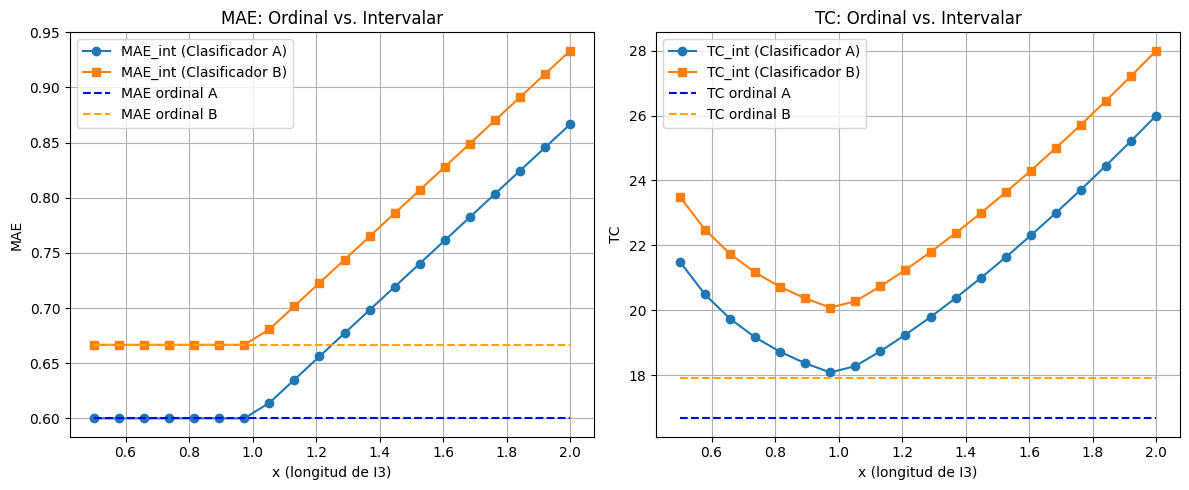

In [9]:
# Gráficas: Evolución de las métricas intervalares vs. x
plt.figure(figsize=(12, 5))

# Gráfica de MAE_int vs. x para ambos clasificadores
plt.subplot(1, 2, 1)
plt.plot(x_vals, mae_A_int_vals, label="MAE_int (Clasificador A)", marker='o')
plt.plot(x_vals, mae_B_int_vals, label="MAE_int (Clasificador B)", marker='s')
plt.hlines(mae_A_ord, x_vals[0], x_vals[-1], linestyles='dashed', colors='blue', label="MAE ordinal A")
plt.hlines(mae_B_ord, x_vals[0], x_vals[-1], linestyles='dashed', colors='orange', label="MAE ordinal B")
plt.xlabel("x (longitud de I3)")
plt.ylabel("MAE")
plt.title("MAE: Ordinal vs. Intervalar")
plt.legend()
plt.grid(True)

# Gráfica de TC_int vs. x para ambos clasificadores
plt.subplot(1, 2, 2)
plt.plot(x_vals, tc_A_int_vals, label="TC_int (Clasificador A)", marker='o')
plt.plot(x_vals, tc_B_int_vals, label="TC_int (Clasificador B)", marker='s')
plt.hlines(tc_A_ord, x_vals[0], x_vals[-1], linestyles='dashed', colors='blue', label="TC ordinal A")
plt.hlines(tc_B_ord, x_vals[0], x_vals[-1], linestyles='dashed', colors='orange', label="TC ordinal B")
plt.xlabel("x (longitud de I3)")
plt.ylabel("TC")
plt.title("TC: Ordinal vs. Intervalar")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Conclusiones

**Métricas ordinales:**
- Tanto **MAE** como **TC** se calculan en función de la diferencia de etiquetas (|i – j|) y no dependen de la longitud de los intervalos; por ello, sus valores se mantienen constantes al variar *x*.

**Métricas intervalares:**
- Se incorporan la longitud de los intervalos (a través de la función de distancia entre intervalos) y la “densidad” (n_j/ℓ_j).
- En el ejemplo, al aumentar *x* se modifica la distancia entre I₁ e I₃ y entre I₂ e I₃, afectando tanto **MAE_int** como **TC_int**.

- Aunque en el ejemplo toy la diferencia absoluta en **TC_int** entre los clasificadores A y B resulta independiente de *x*, al normalizar la métrica (dividir por el máximo teórico) esta diferencia relativa podría variar, resaltando la importancia de elegir adecuadamente el límite del intervalo para maximizar la capacidad discriminativa de la métrica.

Este notebook ilustra la implementación y comparación práctica de ambas ideas métricas.